# 02 — Baselines: the bar every model must beat
**EM 630 · Electricity Demand Forecasting · Phase 3**

**Why baselines?** A forecasting model is only useful if it beats what you could do *without* a model. Load is extremely persistent (Fig 8: autocorrelation at lag 1 = 0.98), so even "next hour = this hour" looks impressive on paper. Without a baseline, an R² of 0.99 tells you nothing.

We build five baselines, none of which involves machine learning:

| Baseline | Forecast for target hour $h$ | Parameters learned |
|---|---|---|
| **Naive-1** (persistence) | $\hat y_h = y_{h-1}$ | 0 |
| **Seasonal naive-24** | $\hat y_h = y_{h-24}$ | 0 |
| **Seasonal naive-168** | $\hat y_h = y_{h-168}$ | 0 |
| **Calendar climatology** | mean load for the same (hour, weekday, month) | 2,016 cell means |
| **Naive-1 + hourly step** | $\hat y_h = y_{h-1} + \overline{\Delta}_{hour(h),\,month(h)}$ | 288 average steps |

All "learned" quantities are fitted on data **strictly before** the period being forecast: Train for scoring Val, Train+Val for scoring Test.

In [1]:
import sys, inspect, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from IPython.display import Image, display
from src import baselines, config, data, evaluation as ev, features, split
from src.metrics import evaluate
pd.set_option("display.precision", 2)

def show(name, width=900):
    display(Image(filename=str(config.FIG_DIR / f"{name}.png"), width=width))

hourly = data.load_clean()
feats = features.build_features(hourly)
sp = split.chronological_split(feats)
T = config.TARGET
print(f"Val : {sp.val.index.min():%d %b %Y} → {sp.val.index.max():%d %b %Y}  ({len(sp.val):,} h)")
print(f"Test: {sp.test.index.min():%d %b %Y} → {sp.test.index.max():%d %b %Y}  ({len(sp.test):,} h)")

Val : 18 Mar 2025 → 26 Jun 2025  (2,381 h)
Test: 26 Jun 2025 → 12 Jan 2026  (4,762 h)


---
## 1. How we score: metrics and the skill score

| Metric | Formula | Reads as |
|---|---|---|
| MAE | $\frac1n\sum|y-\hat y|$ | average miss in MW (our headline metric) |
| RMSE | $\sqrt{\frac1n\sum(y-\hat y)^2}$ | penalises big misses more; RMSE ≫ MAE means occasional large errors |
| MAPE | $\frac{100}{n}\sum\left|\frac{y-\hat y}{y}\right|$ | average miss in %; safe here because load never approaches 0 |
| R² | $1-\frac{\sum(y-\hat y)^2}{\sum(y-\bar y)^2}$ | share of variance explained |
| Bias | $\frac1n\sum(y-\hat y)$ | > 0 means systematic under-forecasting |
| **Skill** | $1-\mathrm{MAE}_{model}/\mathrm{MAE}_{naive\text{-}1}$ | > 0 means the model beats persistence; this is the honest metric |

One definition is shared by every model:

In [2]:
print(inspect.getsource(evaluate))

def evaluate(y_true, y_pred) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if np.any(y_true <= 0):
        raise ValueError("MAPE undefined: non-positive actual load")
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAPE": float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100),
        "R2": r2_score(y_true, y_pred),
        "Bias": float(np.mean(y_true - y_pred)),   # >0 = under-forecast on average
    }



---
## 2. The three naive forecasts and the v1 off-by-one bug

Because Phase 1 names every feature **relative to the target hour $h$**, a naive forecast is just a column lookup:

In [3]:
print(baselines.NAIVE)
# Independent check: recompute from the raw hourly series instead of the feature table
for name, k in [("Naive-1 (persistence)", 1), ("Seasonal naive-24", 24), ("Seasonal naive-168", 168)]:
    same = np.allclose(baselines.naive_forecasts(sp.test)[name], hourly["load_mw"].shift(k).reindex(sp.test.index))
    print(f"{name:24s} equals y(h-{k}) from raw series: {same}")

{'Naive-1 (persistence)': 'load_lag_1', 'Seasonal naive-24': 'load_lag_24', 'Seasonal naive-168': 'load_lag_168'}
Naive-1 (persistence)    equals y(h-1) from raw series: True
Seasonal naive-24        equals y(h-24) from raw series: True
Seasonal naive-168       equals y(h-168) from raw series: True


**What went wrong in v1.** v1 put features on the row of the *current* hour $t$ but predicted the *next* hour $t+1$. So its column `Lag_24 = MW.shift(24)` was the load at $t-24 = (t+1)-25$. Its "same hour yesterday" was really **one hour off**, and so was its "same hour last week". Reproducing that:

In [4]:
pd.read_csv(config.TABLE_DIR / "phase3_v1_offbyone.csv")

,baseline,v1 used,v1 MAE,fixed MAE,v1 overstated error by
0,naive-24,h-25,330.69,247.11,+33.8%
1,naive-168,h-169,477.16,413.91,+15.3%


✅ v1 overstated the seasonal-naive error by about **34%** (daily) and about **15%** (weekly), which made its ML models look better *relative to* those baselines than they were. With our naming convention this bug cannot happen.

---
## 3. Calendar climatology: "what's normal for this hour?"

In [5]:
print(inspect.getsource(baselines.CalendarClimatology))

class CalendarClimatology:
    """Average load for the same (hour, weekday, month), learned from past data only.
    Falls back to (hour, month), then (hour,) if a cell was never seen."""

    def fit(self, part: pd.DataFrame):
        y = part[config.TARGET]
        self.levels_ = [CLIM_KEYS, ["hour", "month"], ["hour"]]
        self.tables_ = [y.groupby([part[k] for k in keys]).mean() for keys in self.levels_]
        self.fit_end_ = part.index.max()
        return self

    def predict(self, part: pd.DataFrame) -> pd.Series:
        pred = pd.Series(index=part.index, dtype=float)
        for keys, table in zip(self.levels_, self.tables_):
            missing = pred.isna()
            if not missing.any():
                break
            idx = pd.MultiIndex.from_frame(part.loc[missing, keys]) if len(keys) > 1 else part.loc[missing, keys[0]]
            pred[missing] = table.reindex(idx).values
        return pred



💡 Climatology has **no memory**: it predicts the same value for every Tuesday 10:00 in July, whatever happened yesterday. It cannot follow a heatwave or a year-to-year level change. Watch its **bias** in the results: it is large and positive (it under-forecasts), because the test period sits above the average level of past years.

---
## 4. A discovery: load steps on a schedule

Persistence (naive-1) error is not smooth across the day (Fig 13): it spikes at fixed hours. Let's look at the average change from one hour to the next, by hour of day:

In [6]:
def step_table(part):
    d = part[T] - part["load_lag_1"]
    return d.groupby(part["hour"]).agg(["mean", "std"])

st = pd.concat({"train": step_table(sp.train), "test": step_table(sp.test)}, axis=1).round(0)
st.T

hour           0      1      2      3      4      5      6      7      8   \
train mean -273.0 -279.0 -217.0 -169.0  -53.0  141.0  282.0  170.0  106.0   
      std   278.0   89.0   96.0  108.0  189.0  334.0  461.0  319.0  134.0   
test  mean -249.0 -323.0 -242.0 -190.0  -63.0  150.0  319.0  184.0  151.0   
      std   121.0  109.0  112.0  108.0  172.0  325.0  398.0  277.0  139.0   

hour           9   ...     14     15    16     17     18     19     20     21  \
train mean  412.0  ...   82.0    0.0 -66.0    6.0  -76.0  -64.0  -90.0  -33.0   
      std   171.0  ...  267.0  106.0  80.0  230.0  219.0  128.0  176.0  290.0   
test  mean  459.0  ...   66.0  -12.0 -79.0   35.0  -43.0  -45.0 -115.0  -48.0   
      std   165.0  ...  249.0  110.0  99.0  220.0  136.0   98.0  168.0  274.0   

hour           22     23  
train mean   31.0 -104.0  
      std   250.0  196.0  
test  mean    5.0 -154.0  
      std   203.0  191.0  

[4 rows x 24 columns]

✅ **Finding.** At 09:00, load jumps by about **+410 MW in Train and +460 MW in Test**, with a spread (std) of only about 170 MW. Similar fixed steps occur at 00:00–02:00 (down, about −250 MW each hour), 06:00 (up, about +300 MW) and 23:00 (down). The steps are **large, regular and stable from Train to Test**. This pattern is consistent with scheduled load switching, such as rotating feeder supply schedules.

💡 **Why this matters.** Persistence ignores the clock, so it misses every scheduled jump by its full size. Adding the *average* step for that hour (and month, since the schedule shifts with the season) fixes most of that. It is still not machine learning, just a lookup table of 24 × 12 numbers:

In [7]:
print(inspect.getsource(baselines.PersistencePlusStep))

class PersistencePlusStep:
    """y_hat(h) = y(h-1) + average change from hour h-1 to hour h, by (hour, month).

    Captures the scheduled step changes in load (e.g. +~400 MW at 09:00) that pure
    persistence always misses. 24 x 12 numbers learned from past data only; no ML."""

    def fit(self, part: pd.DataFrame):
        step = part[config.TARGET] - part["load_lag_1"]
        self.by_hm_ = step.groupby([part["hour"], part["month"]]).mean()
        self.by_h_ = step.groupby(part["hour"]).mean()
        self.fit_end_ = part.index.max()
        return self

    def predict(self, part: pd.DataFrame) -> pd.Series:
        idx = pd.MultiIndex.from_frame(part[["hour", "month"]])
        step = pd.Series(self.by_hm_.reindex(idx).values, index=part.index)
        step = step.fillna(part["hour"].map(self.by_h_))
        return part["load_lag_1"] + step



---
## 5. Results

In [8]:
tab = pd.read_csv(config.TABLE_DIR / "phase3_baselines.csv")
cols = ["model", "MAE", "RMSE", "MAPE", "R2", "Bias", "skill_vs_naive1"]
for s in ["val", "test"]:
    print(f"\n{s.upper()} — all hours")
    display(tab[(tab.split == s) & (tab.subset == "all")][cols].sort_values("MAE").reset_index(drop=True))
print("TEST — peak hours (load ≥ train 90th percentile)")
display(tab[(tab.split == "test") & (tab.subset == "peak")][["model", "n", "MAE", "MAPE", "Bias"]].sort_values("MAE").reset_index(drop=True))


VAL — all hours


,model,MAE,RMSE,MAPE,R2,Bias,skill_vs_naive1
0,Naive-1 + hourly step,94.15,147.22,1.98,0.98,0.65,0.51
1,Naive-1 (persistence),192.43,253.08,3.95,0.95,1.02,0.00
2,Seasonal naive-24,319.54,466.37,6.40,0.84,37.85,-0.66
3,Calendar climatology,571.16,722.51,11.48,0.62,292.07,-1.97
4,Seasonal naive-168,590.86,781.94,11.43,0.56,217.91,-2.07



TEST — all hours


,model,MAE,RMSE,MAPE,R2,Bias,skill_vs_naive1
0,Naive-1 + hourly step,74.31,104.28,1.77,0.99,2.16,0.64
1,Naive-1 (persistence),204.68,265.20,5.05,0.96,0.42,0.00
2,Seasonal naive-24,247.11,371.22,5.33,0.92,-8.76,-0.21
3,Calendar climatology,396.83,503.67,8.89,0.85,116.06,-0.94
4,Seasonal naive-168,413.91,592.30,8.99,0.79,-72.93,-1.02


TEST — peak hours (load ≥ train 90th percentile)


,model,n,MAE,MAPE,Bias
0,Naive-1 + hourly step,588,66.26,1.01,8.61
1,Naive-1 (persistence),588,193.48,2.95,46.69
2,Seasonal naive-24,588,317.33,4.83,162.82
3,Seasonal naive-168,588,583.56,8.86,413.87
4,Calendar climatology,588,648.61,9.82,621.12


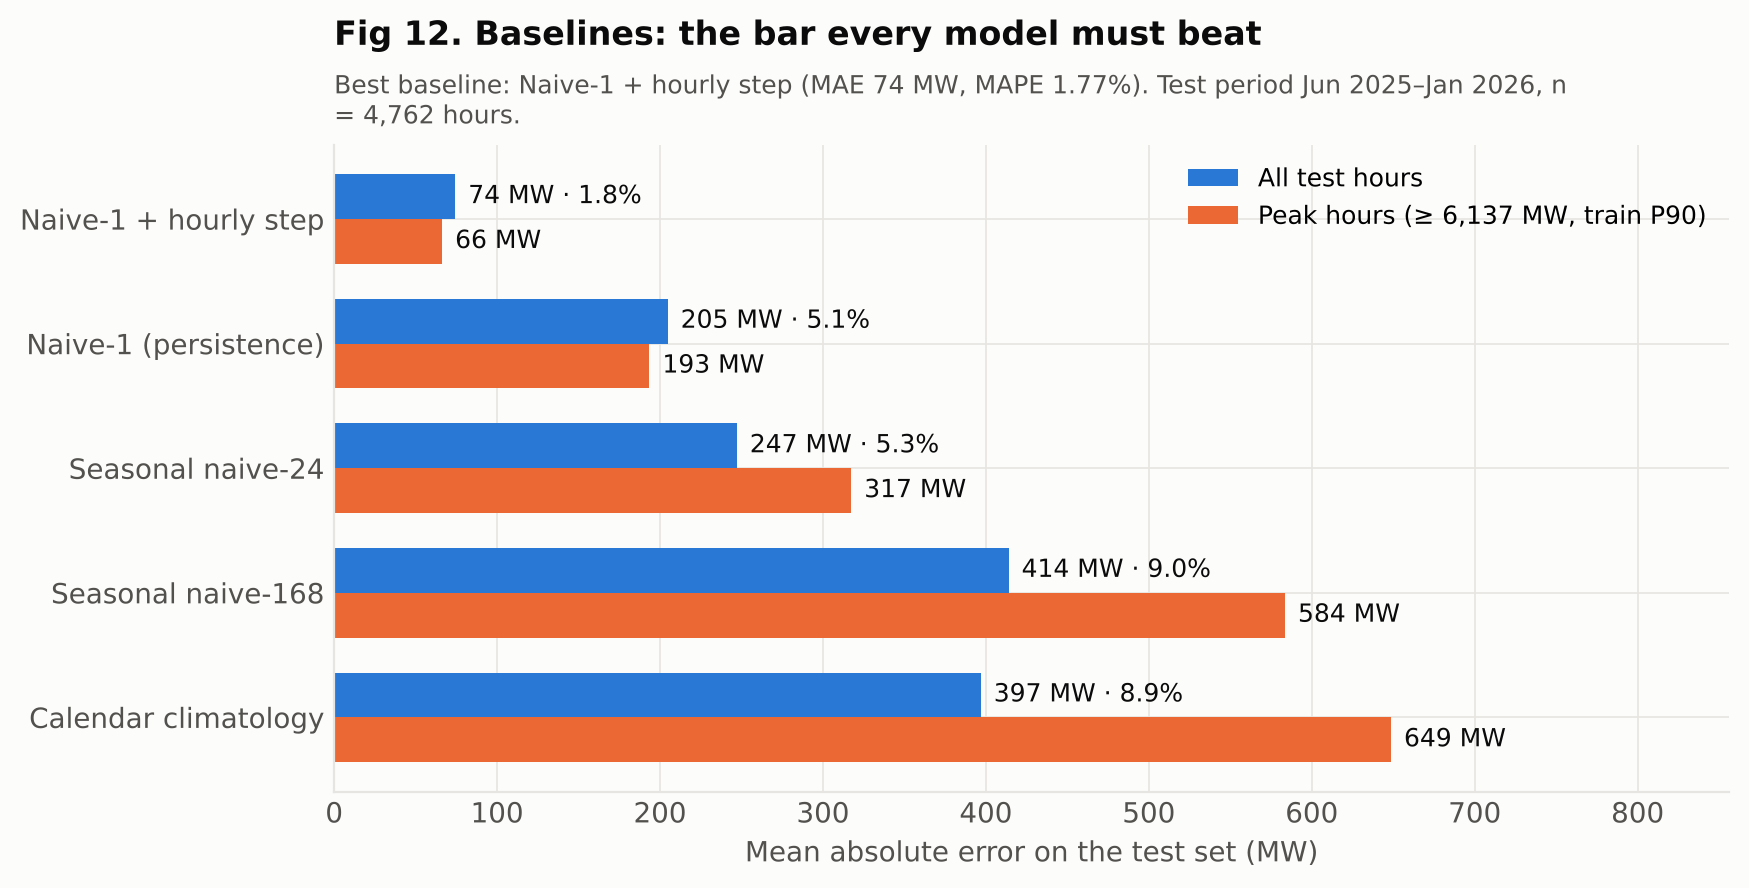

In [9]:
show("F12_baselines_mae")

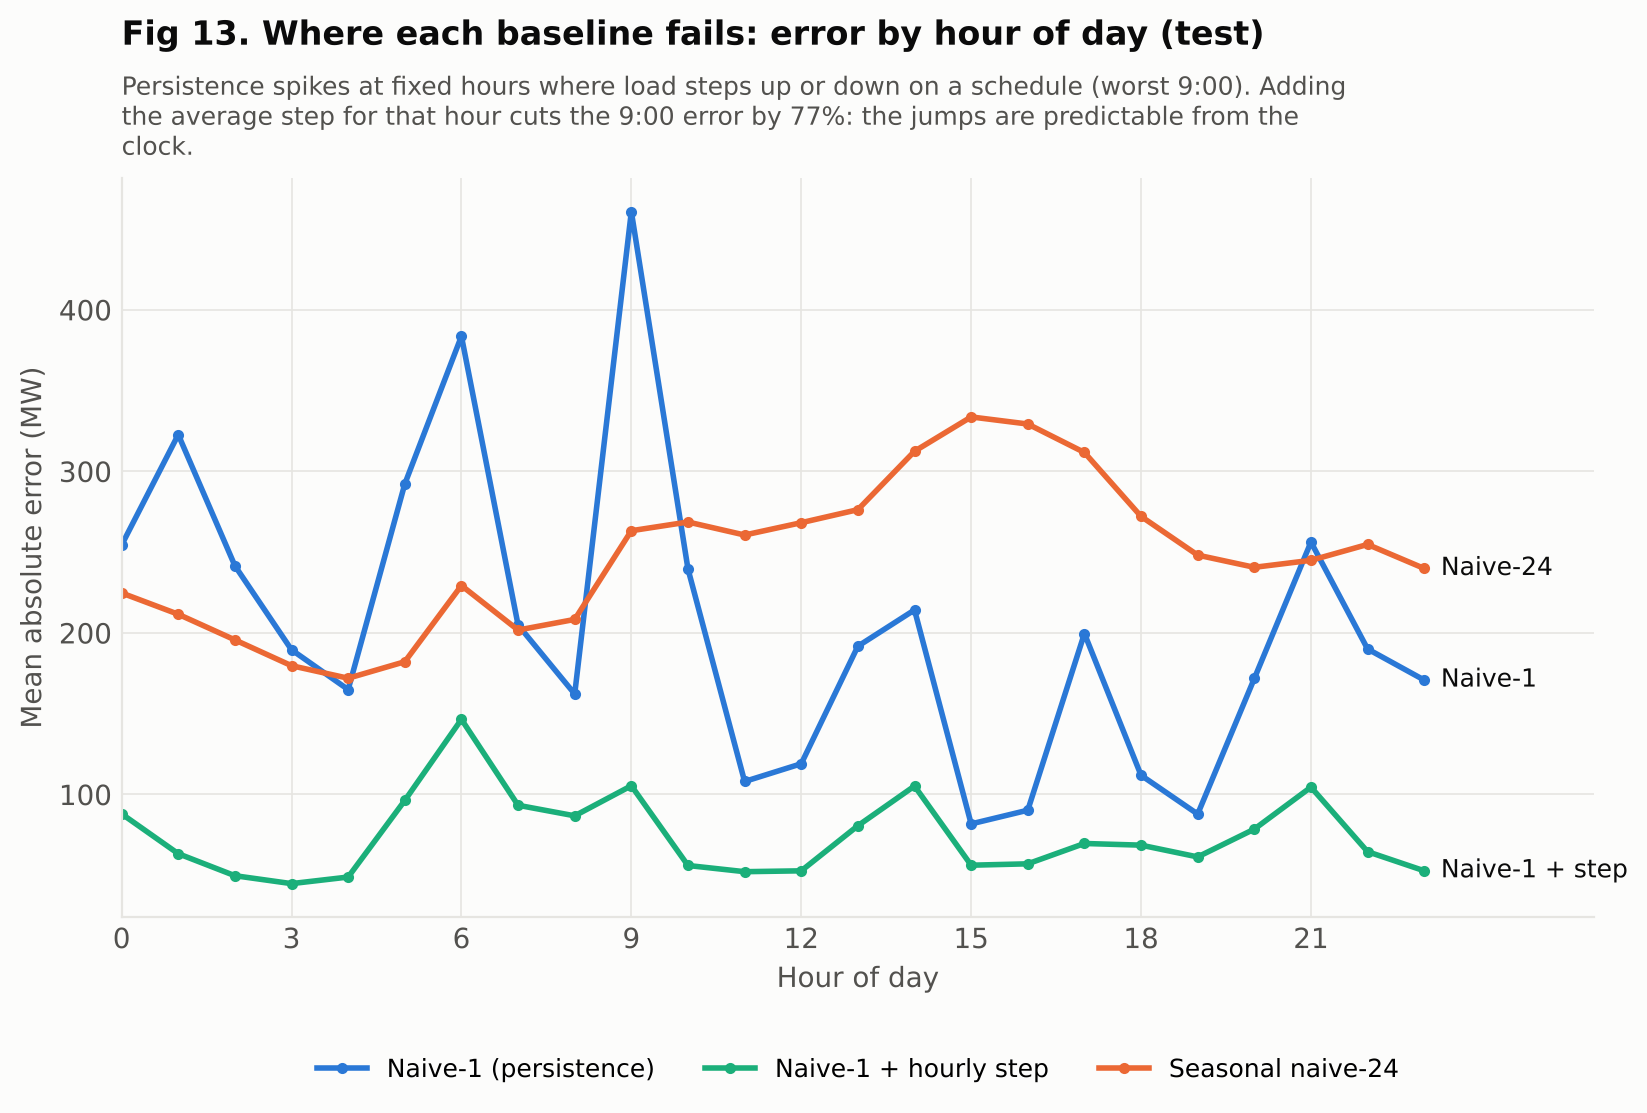

In [10]:
show("F13_baselines_by_hour")

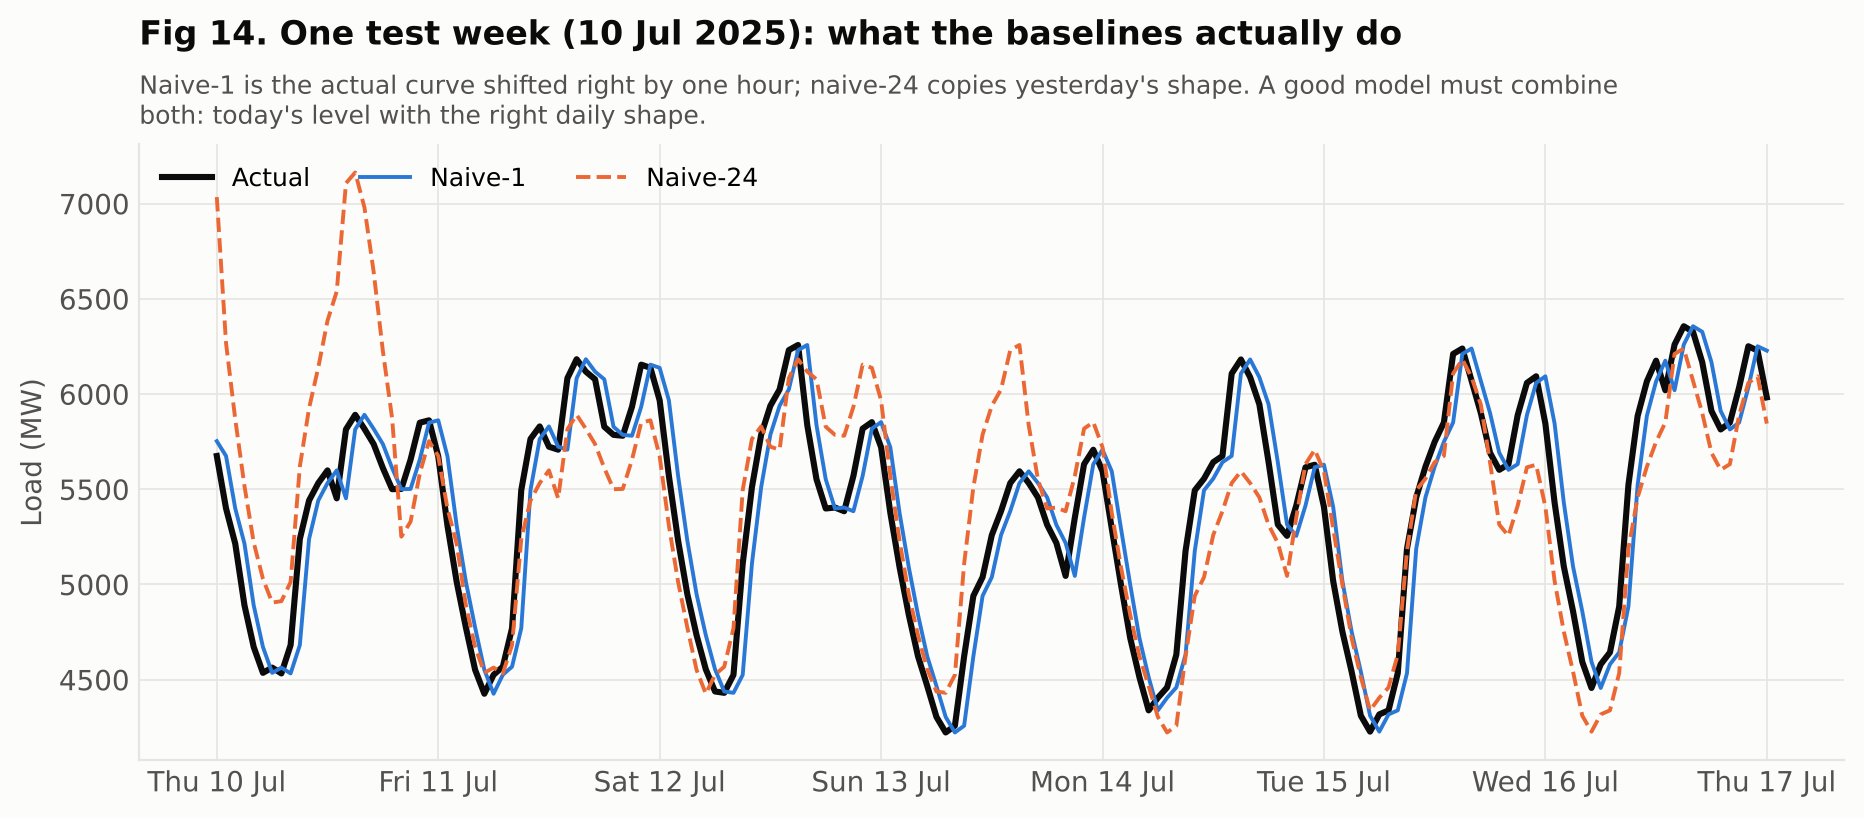

In [11]:
show("F14_baselines_week", 1000)

✅ **Findings**
1. **Naive-1 + hourly step is by far the strongest baseline:** test MAE ≈ 74 MW (1.8%), 64% better than persistence, and also the best on peak hours.
2. **Persistence beats both seasonal naives**, and naive-24 beats naive-168. Both match the EDA expectations (Fig 8: lag 1 > lag 24 > lag 168).
3. **R² is misleading here.** Even plain persistence scores R² ≈ 0.96, so any model looks excellent on R². That is why we report MAE and **skill vs persistence**.
4. Climatology under-forecasts (Bias > 0) because it can't track the current level, which is the point of memory-based features.

⚠️ **The evaluator's most important note.** v1's **tuned XGBoost** reported **MAE 74.4 MW, MAPE 1.75%**, essentially *the same* as this 288-number lookup table. On roughly the same test period, v1's best model did not clearly beat a simple non-ML baseline. In the report, ML only counts as successful if it beats **74 MW**, not 205 MW.

---
## 6. Is anything left for ML to learn?
If the step baseline's errors were pure noise, no model could do better. We test this by looking for structure in its residuals:

In [12]:
from statsmodels.tsa.stattools import acf
m = baselines.PersistencePlusStep().fit(sp.dev)
resid = sp.test[T] - m.predict(sp.test)
full = resid.reindex(pd.date_range(resid.index.min(), resid.index.max(), freq="h")).interpolate()
r_acf = acf(full, nlags=24, fft=True)
print(f"Residual autocorrelation: lag1 = {r_acf[1]:.2f}, lag2 = {r_acf[2]:.2f}, lag24 = {r_acf[24]:.2f}")
pd.Series({c: np.corrcoef(sp.test[c], resid)[0, 1] for c in
           ["load_ramp_1", "load_lag_1", "load_lag_24", "temp_lag_1", "is_festival"]}).round(3).to_frame("corr with residual").T

Residual autocorrelation: lag1 = 0.48, lag2 = 0.24, lag24 = 0.39


,load_ramp_1,load_lag_1,load_lag_24,temp_lag_1,is_festival
corr with residual,0.24,-0.1,-0.04,-0.01,-0.01


✅ **Finding.** Yes. The residuals are **autocorrelated** (lag 1 ≈ 0.48, lag 24 ≈ 0.39) and correlate with recent **momentum** (`load_ramp_1`). Errors come in runs, so recent history still holds information the lookup table ignores. Weather and festival flags show almost nothing, consistent with the EDA.

🔧 **What the ML models must do (Phases 4–6):** learn (1) the scheduled steps, and they get these from the hour features, plus (2) the momentum and the persistence of deviations that the lookup table misses.

| Bar | Test MAE | Meaning |
|---|---|---|
| Naive-1 (persistence) | ≈ 205 MW | the minimum; any model must beat this |
| **Naive-1 + hourly step** | **≈ 74 MW** | **the real bar**: an ML model must beat this to justify itself |
| v1 tuned XGBoost (for reference) | 74.4 MW | did not clear the real bar |